# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Evan Wu

**ID**: 5839048

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [24]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\evant\OneDrive\Documents\GitHub\hw3-evtw`


In [25]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Streeter-Phelps solution:
$$ U\frac{dC}{dx} = k_a(C_s-C) + P - R - S_B - k_c B_0 exp(\frac{-k_cx}{U}) - k_n N_0 exp(\frac{-k_nx}{U}) $$

In this model, we ignore $P,R,S_B$. 
$$ U\frac{dC}{dx} = k_a(C_s-C) - k_c B_0 exp(\frac{-k_cx}{U}) - k_n N_0 exp(\frac{-k_nx}{U}) $$
From the known variables:
$$ k_a = \frac{0.55}{day}$$
$$ k_c = \frac{0.35}{day}$$
$$ k_n = \frac{0.25}{day}$$
$$ U = \frac{6km}{day}$$
$$ C_s = 10 \frac{mg}{L}$$

Need to split the system into two parts: the stream before Stream 2 is integrated and the river after Stream 2 is added:

Integrating the equation:
$$ C(x) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3 $$
$$ \alpha_1 = exp(-\frac{k_ax}{U}) $$
$$ \alpha_2 = (\frac{k_c}{k_a-k_c})[exp(-\frac{k_cx}{U})-exp(-\frac{k_ax}{U})] $$
$$ \alpha_3 = (\frac{k_n}{k_a-k_n})[exp(-\frac{k_nx}{U})-exp(-\frac{k_ax}{U})] $$

Need to find the initial concentration $C_0$ when $x=0$. Let $x=0$ when the river and Stream 1 just mix:

$$ \alpha_1 = e^{-0} = 1$$
$$ \alpha_2 = (\frac{k_c}{k_a-k_c})(1-1) = 0$$
$$ \alpha_3 = (\frac{k_n}{k_a-k_n})(1-1) = 0$$
$$ C(x) = C_0 $$

Initial concentration of DO:
River mass Inflow: $100000{m^3}\times1000\frac{L}{m^3}=100,000,000L$

Stream 1 mass Inflow: $10000{m^3}\times1000\frac{L}{m^3}=10,000,000L$

River DO Inflow: $100,000,000{L}\times7.5\frac{mg}{L}=750,000,000mg$

Stream 1 DO Inflow: $10,000,000L\times5\frac{mg}{L}=50,000,000mg$

$$ C_0 = 750,000,000mg + 50,000,000mg = 800,000,000mg$$

Initial concentration of $C_0,B_0,N_0$:

$$ C_0 = 7.5 \frac{mg}{L} \times \frac{10}{11} + 5 \frac{mg}{L} \times \frac{1}{11} \approx 7.27 \frac{mg}{L} $$
$$ B_0 = 5 \frac{mg}{L} \times \frac{10}{11} + 50 \frac{mg}{L} \times \frac{1}{11} \approx 9.09 \frac{mg}{L} $$
$$ N_0 = 5 \frac{mg}{L} \times \frac{10}{11} + 35 \frac{mg}{L} \times \frac{1}{11} \approx 7.73 \frac{mg}{L} $$

Next, we need to consider the system after Stream 2 is added when x = 15km. First, the concentration of the river before Stream 2 is added must be calculated:
$$ C(x=15) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3 $$
$$ \alpha_1 = e^{-\frac{0.55\times 15}{6}} \approx 0.252$$
$$ \alpha_2 = \frac{0.35}{0.55-0.35}(e^{-\frac{0.35\times15}{6}}-e^{-\frac{0.55\times15}{6}}) \approx 0.287$$
$$ \alpha_3 = \frac{0.25}{0.55-0.25}(e^{-\frac{0.25\times15}{6}}-e^{-\frac{0.55\times15}{6}}) \approx 0.235$$
Calculating the concentration of the river before Stream 2 is added:
$$ C(x=15) = 10(1-0.252) + 7.27(0.252) - 9.09(0.287) - 7.73(0.235) \approx 4.89 \frac{mg}{L}$$

New system equation after Stream 2 is added:
$$ C(x) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3 $$
$$ \alpha_1 = exp(-\frac{k_a(x-15)}{U}) $$
$$ \alpha_2 = (\frac{k_c}{k_a-k_c})[exp(-\frac{k_c(x-15)}{U})-exp(-\frac{k_a(x-15)}{U})] $$
$$ \alpha_3 = (\frac{k_n}{k_a-k_n})[exp(-\frac{k_n(x-15)}{U})-exp(-\frac{k_a(x-15)}{U})] $$
We subtract x by 15 as the mixing starts at x = 15. The initial concentrations after the river and Stream 2 need to be calculated:
$$ C_0 = 4.89 \frac{mg}{L} \times \frac{110}{125} + 5 \frac{mg}{L} \times \frac{15}{125} \approx 4.90 \frac{mg}{L}$$
$$ B_0 = 9.09(1-0.287) \frac{mg}{L} \times \frac{110}{125} + 45 \frac{mg}{L} \times \frac{15}{125} \approx 11.10 \frac{mg}{L}$$
$$ B_0 = 7.73(1-0.235) \frac{mg}{L} \times \frac{110}{125} + 35 \frac{mg}{L} \times \frac{15}{125} \approx 9.40 \frac{mg}{L}$$
With these two system equations, it is possible to plot the dissolved oxygen concentration over distance downstream

2.8358280713478363


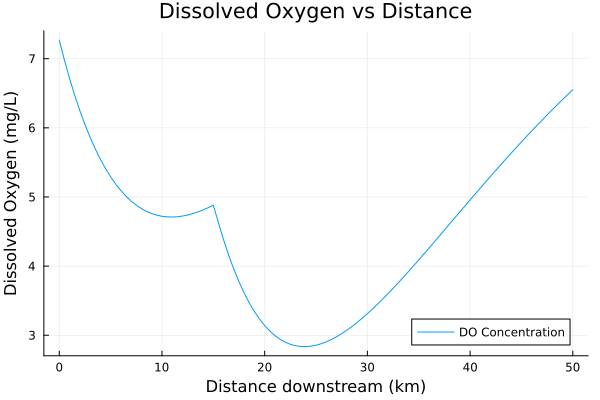

In [26]:
# Equation constants:
k_a = 0.55
k_c = 0.35
k_n = 0.25
C_s = 10 # mg/L
U = 6 # km/d

# System 1:
C1_0 = 7.27 # mg/L
B1_0 = 9.09 # mg/L
N1_0 = 7.73 # mg/L

# System 2:
C2_0 = 4.90 # mg/L
B2_0 = 11.10 # mg/L
N2_0 = 9.40 # mg/L

distance_range = [0:0.5:50;];
DO_values = [];

for d in distance_range
    if d <= 15
        alpha1 = exp(-k_a * d / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d / U) - exp(-k_a * d / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d / U) - exp(-k_a * d / U))
        
        C = C_s*(1-alpha1) + C1_0*alpha1 - B1_0*alpha2 - N1_0*alpha3
        push!(DO_values, C)
    else
        d_adjusted = d - 15
        alpha1 = exp(-k_a * d_adjusted / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d_adjusted / U) - exp(-k_a * d_adjusted / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d_adjusted / U) - exp(-k_a * d_adjusted / U))

        C = C_s*(1-alpha1) + C2_0*alpha1 - B2_0*alpha2 - N2_0*alpha3
        push!(DO_values, C)
    end
end

println(minimum(DO_values))
plot(distance_range, DO_values, xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="Dissolved Oxygen vs Distance", label="DO Concentration",legend=true)

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

Numerical integrated solution will be utilizing the Forward Euler discretization.
$$ U\frac{dC}{dx} = k_a(C_s-C) - k_c B_0 exp(\frac{-k_cx}{U}) - k_n N_0 exp(\frac{-k_nx}{U}) $$
$$ \frac{dC}{dx} = \frac{k_a}{U}(C_s-C) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U}) $$

$$ As \frac{dC}{dx}\approx\frac{\Delta C(x)}{\Delta{x}}=\frac{C(x+\Delta t)-C(x)}{\Delta x}$$
$$ \frac{C(x+\Delta t)-C(x)}{\Delta x} = \frac{k_a}{U}(C_s-C(x)) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U}) $$
$$ C(x+\Delta t)-C(x) = \Delta x [\frac{k_a}{U}(C_s-C(x)) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U})] $$
$$ C(x+\Delta t) = C(x) + \Delta x [\frac{k_a}{U}(C_s-C(x)) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U})] $$

For t = 0.5,
$$ C(x+0.5) = C(x) + 0.5[\frac{k_a}{U}(C_s-C(x)) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U})] $$

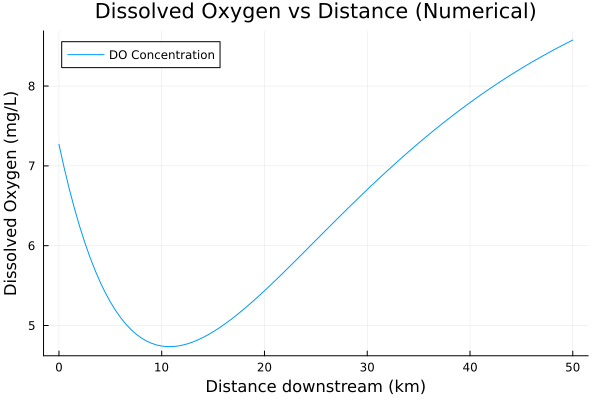

In [ ]:
# Equation constants:
k_a = 0.55
k_c = 0.35
k_n = 0.25
C_s = 10 # mg/L
U = 6 # km/d

function simulate_timestep(C, C0, B0, N0)
    return k_a/U*(C_s - C) - k_c/U*B0*exp(-k_c*C0/U) - k_n/U*N0*exp(-k_n*C0/U)
end

function simulate_wastewater(C0, B0, N0, distance, dx)
    steps = Int64(distance / dx)
    C = zeros(steps + 1)
    C[1] = C0
    for i in 1:steps
        C[i+1] = C[i] + dx * simulate_timestep(C[i], i*dx, B0, N0)
    end
    return C
end

simulate_wastewater(7.27, 9.09, 7.73, 50, 0.5)

plot(distance_range, simulate_wastewater(7.27, 9.09, 7.73, 50, 0.5), xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="Dissolved Oxygen vs Distance (Numerical)", label="DO Concentration",legend=true)

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

## References

List any external references consulted, including classmates.